In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def load_mp4_to_numpy(mp4_path, max_frames=None):
    """
    Loads an mp4 file and converts it to a numpy array of frames.
    
    Args:
        mp4_path (str): Path to the mp4 video.
        max_frames (int, optional): Maximum number of frames to load. If None, load all frames.
        
    Returns:
        frames (np.ndarray): Array of shape (num_frames, H, W, 3) with dtype=np.uint8.
    """
    cap = cv2.VideoCapture(mp4_path)
    frames = []
    count = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        # Convert BGR (OpenCV default) to RGB for matplotlib
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame)
        count += 1
        if max_frames is not None and count >= max_frames:
            break
    cap.release()
    if frames:
        return np.stack(frames)
    else:
        return np.array([])


In [17]:
metadata_trainval_path = r"D:\PVOutputPrediction\preprocessing\data\data_forecast4\metadata_trainval\metadata_with_cloudiness.parquet"
metadata_test_path = r"D:\PVOutputPrediction\preprocessing\data\data_forecast4\metadata_test\metadata.parquet"

df_trainval = pd.read_parquet(metadata_trainval_path)
df_test = pd.read_parquet(metadata_test_path)

In [20]:
print(df_trainval["cloudiness"][120000])

0.006014644351464435


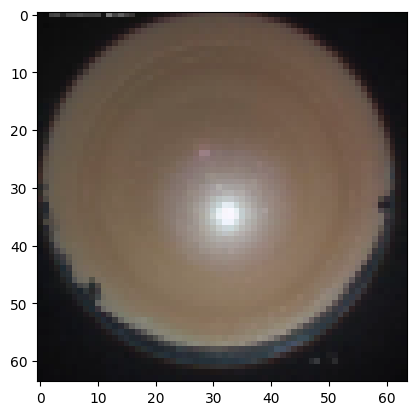

nan


In [9]:
i = 2023
mp4_path = f"D:/PVOutputPrediction/preprocessing/data/data_forecast_64/videos_trainval/sequence_{i:06d}.mp4"
vid_frames = load_mp4_to_numpy(mp4_path)

plt.imshow(vid_frames[0])
plt.show()

print(df_trainval["cloudiness"][i])